## Phase 4 — Model Explainability (SHAP)
#### IEEE-CIS Fraud Detection Dataset

SHAP (SHapley Additive exPlanations) explains WHY the model
made each prediction — which features pushed the score up or down.
This is critical for financial fraud systems where you must justify decisions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

print("✅ Libraries imported")
print(f"   SHAP version : {shap.__version__}")

✅ Libraries imported
   SHAP version : 0.52.0


### Load Model and Data

In [5]:
# Load the best model
import glob

# Find whichever model was saved
model_files = glob.glob('../models/best_model_*.pkl')
if not model_files:
    raise FileNotFoundError("No model found in ../models/ — run Phase 3 first!")

model_path = model_files[0]
model      = joblib.load(model_path)
model_name = model_path.split('best_model_')[1].replace('.pkl','').title()

# Load feature column names
feature_cols = joblib.load('../models/feature_columns.pkl')

# Load metrics
with open('../models/metrics.json') as f:
    metrics = json.load(f)

# Load cleaned data
df = pd.read_parquet('../data/processed/train_features.parquet')

print(f"✅ Model loaded    : {model_name}")
print(f"✅ Features loaded : {len(feature_cols)} columns")
print(f"✅ Metrics loaded  : AUC-ROC = {metrics['auc_roc']}")

✅ Model loaded    : Xgboost
✅ Features loaded : 233 columns
✅ Metrics loaded  : AUC-ROC = 0.9395


## Prepare Data for SHAP

In [6]:
# Prepare features
drop_cols = [c for c in ['TransactionID','isFraud','TransactionDT','card_combo']
             if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['isFraud']

# Keep only the columns the model was trained on
X = X[feature_cols]

# Fix infinity/nan
X = X.replace([np.inf, -np.inf], np.nan).fillna(-999)
X = X.clip(-1e9, 1e9)

# Sample 2000 rows — stratified to include enough fraud cases
fraud_sample = X[y == 1].sample(500,  random_state=42)  # 500 fraud
legit_sample = X[y == 0].sample(1500, random_state=42)  # 1500 legit

X_sample = pd.concat([fraud_sample, legit_sample]).sample(frac=1, random_state=42)
y_sample = y.loc[X_sample.index]

print(f"✅ Sample prepared")
print(f"   Sample size : {X_sample.shape[0]} rows")
print(f"   Fraud       : {y_sample.sum()} ({y_sample.mean()*100:.1f}%)")
print(f"   Features    : {X_sample.shape[1]}")

✅ Sample prepared
   Sample size : 2000 rows
   Fraud       : 500 (25.0%)
   Features    : 233


###  Create SHAP Explainer

In [7]:
print("Creating SHAP TreeExplainer...")
print("This may take 1-2 minutes...\n")

# TreeExplainer works perfectly with XGBoost and LightGBM
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for our sample
# shap_values shape: (n_samples, n_features)
shap_values = explainer.shap_values(X_sample)

# For binary classification some models return list — take fraud class (index 1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"✅ SHAP values calculated")
print(f"   Shape : {shap_values.shape}")
print(f"   Rows  : {shap_values.shape[0]} transactions")
print(f"   Cols  : {shap_values.shape[1]} features")

Creating SHAP TreeExplainer...
This may take 1-2 minutes...

✅ SHAP values calculated
   Shape : (2000, 233)
   Rows  : 2000 transactions
   Cols  : 233 features


 ### Global Feature Importance (Bar Plot)

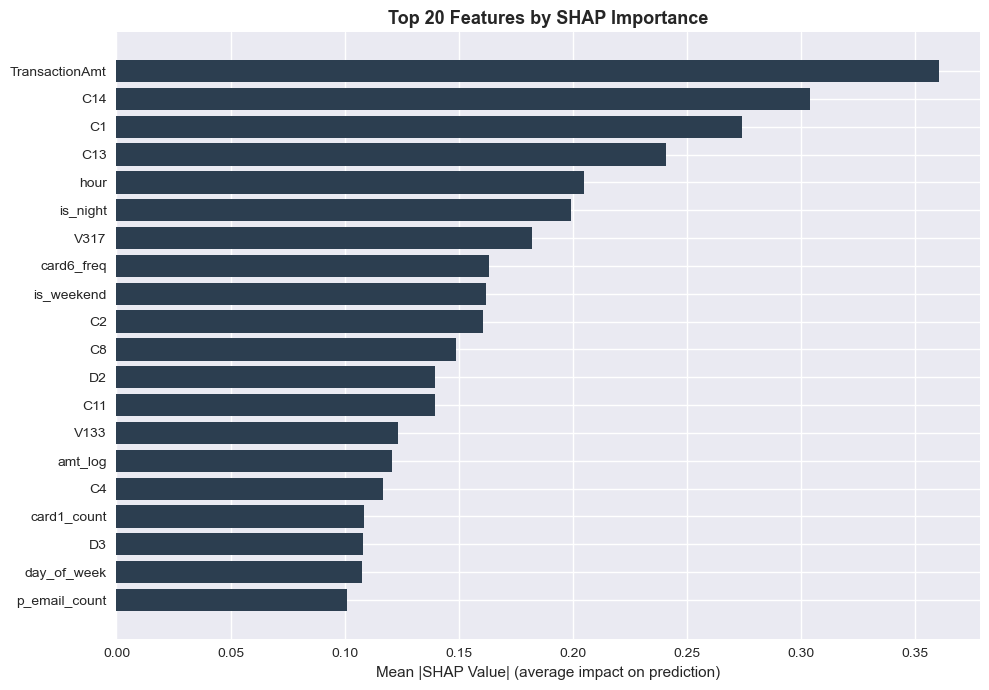

Top 10 most impactful features:
TransactionAmt    0.360385
C14               0.304079
C1                0.274144
C13               0.240644
hour              0.205041
is_night          0.199257
V317              0.182154
card6_freq        0.163268
is_weekend        0.161871
C2                0.160674


In [8]:
# Mean absolute SHAP value per feature = global importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

top20 = shap_importance.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20.index, top20.values, color='#2c3e50')
plt.xlabel('Mean |SHAP Value| (average impact on prediction)')
plt.title('Top 20 Features by SHAP Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most impactful features:")
print(top20.head(10).to_string())

###  SHAP Summary Plot (Beeswarm)

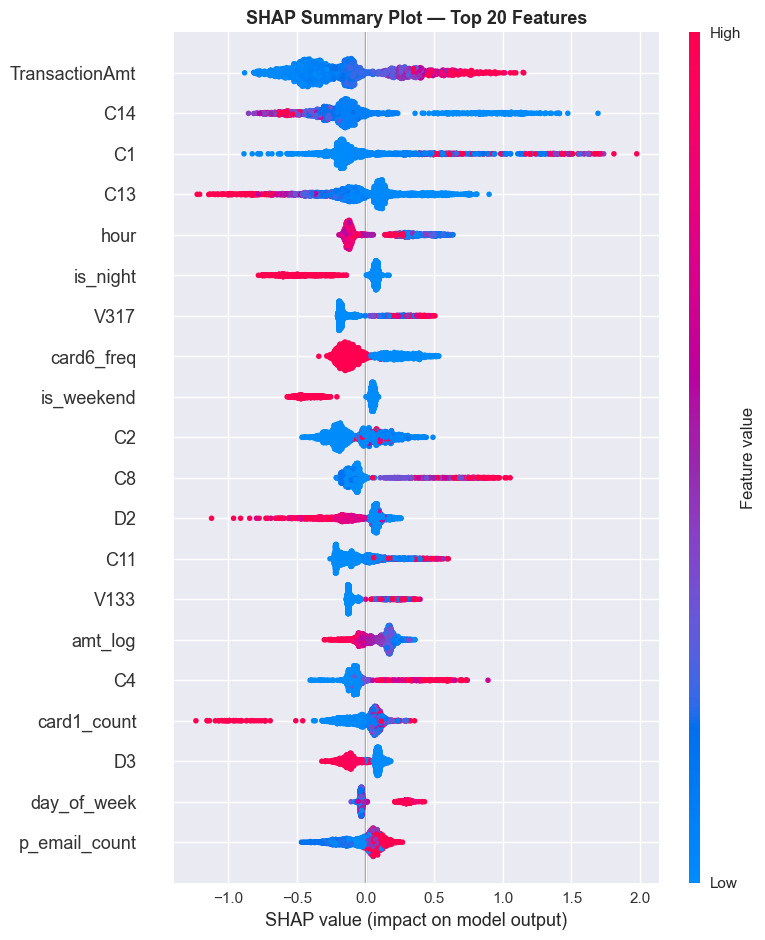

✅ SHAP summary plot saved


In [9]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Summary Plot — Top 20 Features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved")

 ### SHAP Waterfall Plot — Single Transaction Explanation

Explaining transaction index : 1
Fraud probability            : 0.9765 (97.6%)
Actual label                 : FRAUD ✅


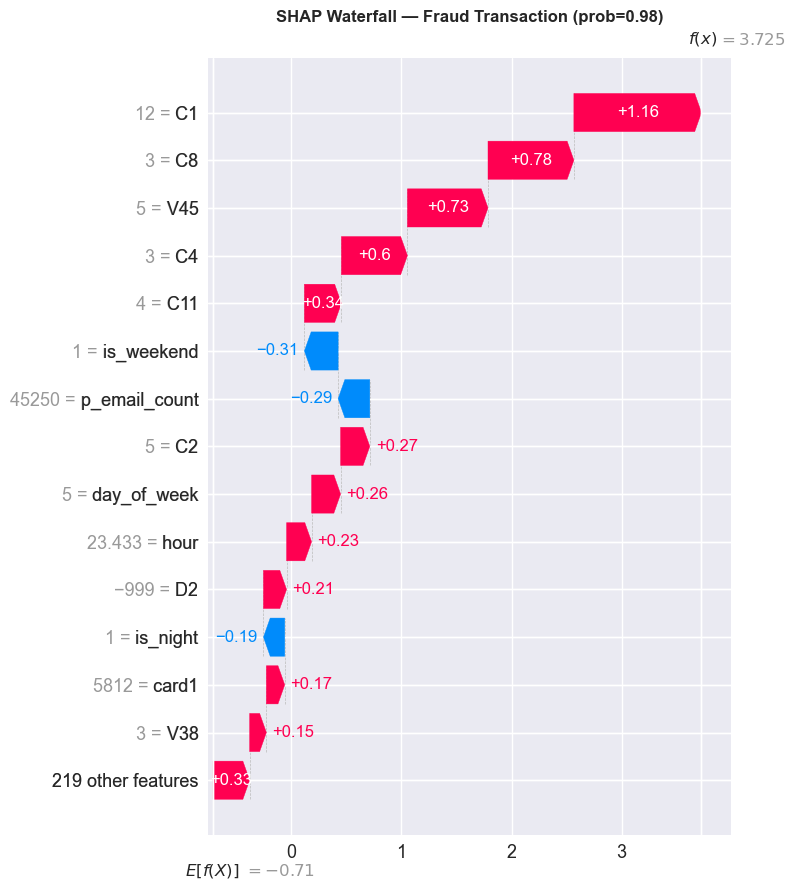

✅ Waterfall plot saved


In [10]:
# Pick one fraud transaction to explain
fraud_indices = np.where(y_sample == 1)[0]
fraud_idx     = fraud_indices[0]  # first fraud in sample

# Get prediction probability
fraud_prob = model.predict_proba(X_sample.iloc[[fraud_idx]])[0][1]

print(f"Explaining transaction index : {fraud_idx}")
print(f"Fraud probability            : {fraud_prob:.4f} ({fraud_prob*100:.1f}%)")
print(f"Actual label                 : FRAUD ✅")

# Waterfall plot
explanation = shap.Explanation(
    values    = shap_values[fraud_idx],
    base_values = explainer.expected_value if not isinstance(
        explainer.expected_value, list) else explainer.expected_value[1],
    data      = X_sample.iloc[fraud_idx].values,
    feature_names = feature_cols
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Fraud Transaction (prob={fraud_prob:.2f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved")

 ### Explain a Legitimate Transaction

Explaining transaction index : 0
Fraud probability            : 0.1074 (10.7%)
Actual label                 : LEGITIMATE ✅


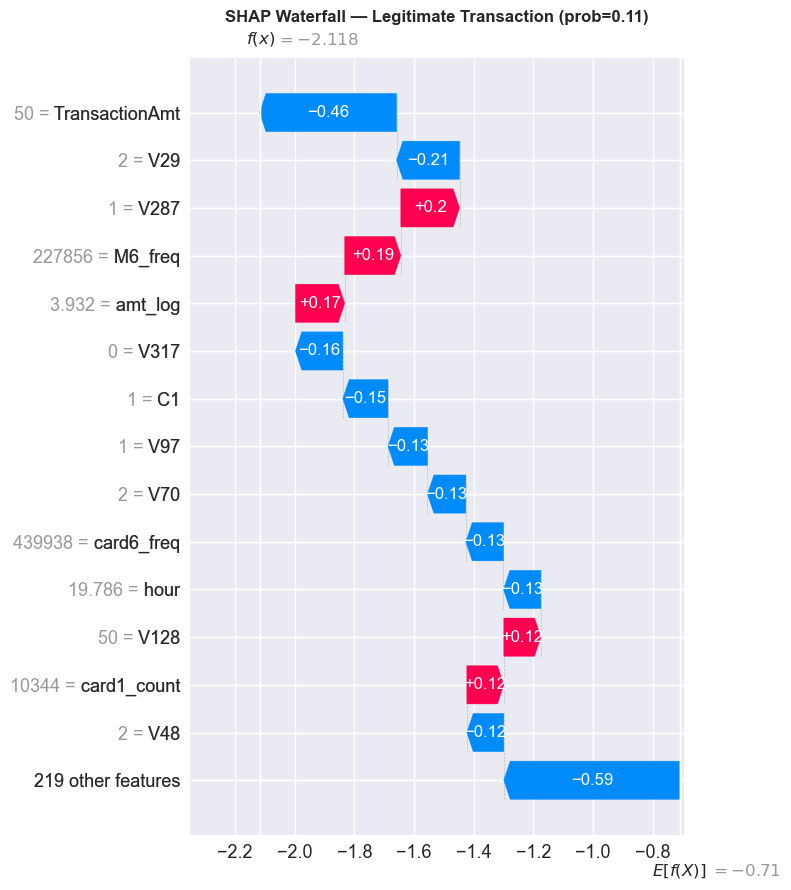

✅ Waterfall plot saved


In [11]:
# Pick one legitimate transaction
legit_indices = np.where(y_sample == 0)[0]
legit_idx     = legit_indices[0]

legit_prob = model.predict_proba(X_sample.iloc[[legit_idx]])[0][1]

print(f"Explaining transaction index : {legit_idx}")
print(f"Fraud probability            : {legit_prob:.4f} ({legit_prob*100:.1f}%)")
print(f"Actual label                 : LEGITIMATE ✅")

explanation_legit = shap.Explanation(
    values      = shap_values[legit_idx],
    base_values = explainer.expected_value if not isinstance(
        explainer.expected_value, list) else explainer.expected_value[1],
    data        = X_sample.iloc[legit_idx].values,
    feature_names = feature_cols
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation_legit, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Legitimate Transaction (prob={legit_prob:.2f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_legit.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved")

###  SHAP Dependence Plot

Plotting dependence for: TransactionAmt


<Figure size 1000x500 with 0 Axes>

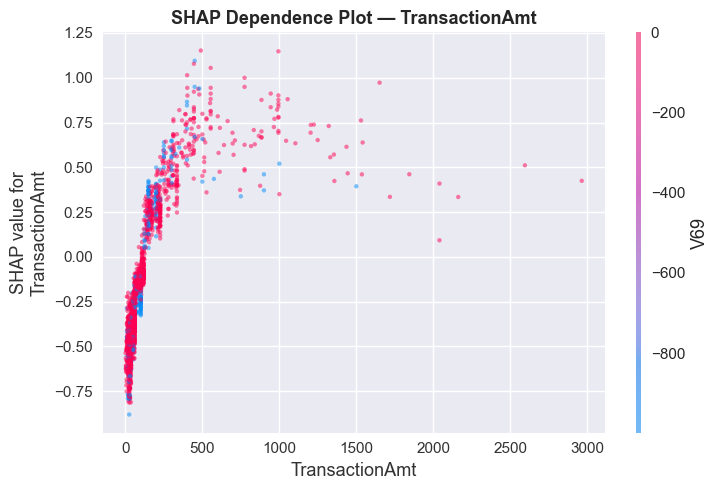

✅ Dependence plot saved


In [12]:
# Use the top feature from SHAP importance
top_feature = shap_importance.index[0]
top_feature_idx = list(feature_cols).index(top_feature)

print(f"Plotting dependence for: {top_feature}")

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_sample,
    feature_names=feature_cols,
    show=False,
    dot_size=10,
    alpha=0.5
)
plt.title(f'SHAP Dependence Plot — {top_feature}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dependence plot saved")

### Save SHAP Explainer for Web App  

In [13]:
os.makedirs('../models', exist_ok=True)

# Save explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save top 20 feature names for the dashboard
top_features_list = shap_importance.head(20).index.tolist()
with open('../models/top_features.json', 'w') as f:
    json.dump(top_features_list, f, indent=2)

# Save SHAP importance for dashboard charts
shap_importance_dict = shap_importance.head(20).to_dict()
with open('../models/shap_importance.json', 'w') as f:
    json.dump(shap_importance_dict, f, indent=2)

print("✅ All SHAP files saved")
print("   shap_explainer.pkl")
print("   top_features.json")
print("   shap_importance.json")
print(f"\nTop 5 most important features:")
for i, feat in enumerate(top_features_list[:5], 1):
    print(f"   {i}. {feat}")

✅ All SHAP files saved
   shap_explainer.pkl
   top_features.json
   shap_importance.json

Top 5 most important features:
   1. TransactionAmt
   2. C14
   3. C1
   4. C13
   5. hour


## Summary

| Chart | What it shows |
|---|---|
| Bar plot | Overall feature importance across all transactions |
| Beeswarm | Importance + direction for each feature |
| Waterfall (fraud) | Why THIS transaction was flagged as fraud |
| Waterfall (legit) | Why THIS transaction was approved |
| Dependence plot | How top feature value affects fraud probability |

All charts saved to `data/processed/`

**Next Step → Phase 5: FastAPI Backend + React Frontend**